# SVI Smile Parameterization

This notebook demonstrates the **Stochastic Volatility Inspired (SVI)** smile
parameterization (Gatheral 2004).  SVI models the total implied variance
$w(k) = \sigma_{BS}^2(k) \cdot T$ as a function of log-moneyness $k = \ln(K/F)$:

$$w(k) = a + b \left(\rho(k-m) + \sqrt{(k-m)^2 + \sigma^2}\right)$$

**Five parameters**: $a$ (level), $b$ (slope), $\rho$ (skew), $m$ (spine), $\sigma$ (curvature).

**Sections:**
1. Raw SVI surface — visualising $w(k)$ and $IV(k)$ for different parameter regimes
2. Parameter sensitivity
3. Butterfly arbitrage check via $g(k)$
4. Single-maturity calibration to a synthetic Heston smile
5. Term structure: fitting SVI to multiple maturities
6. SVI vs SABR comparison on a realistic smile

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import foureng as fe
from foureng.surface.svi import (
    SVIParams,
    svi_total_variance,
    svi_implied_vol,
    svi_butterfly_density,
    svi_check_butterfly_arbitrage,
    fit_svi_smile,
)

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print(f'foureng version: {fe.__version__}')

foureng version: 0.5.0


## 1. Raw SVI Surface

We plot $w(k)$ (total implied variance) and $IV(k, T)$ for three canonical parameter regimes:
- **Flat smile** ($\rho=0$, small $b$)
- **Negative skew** ($\rho < 0$, equity-style)
- **Positive skew** ($\rho > 0$)

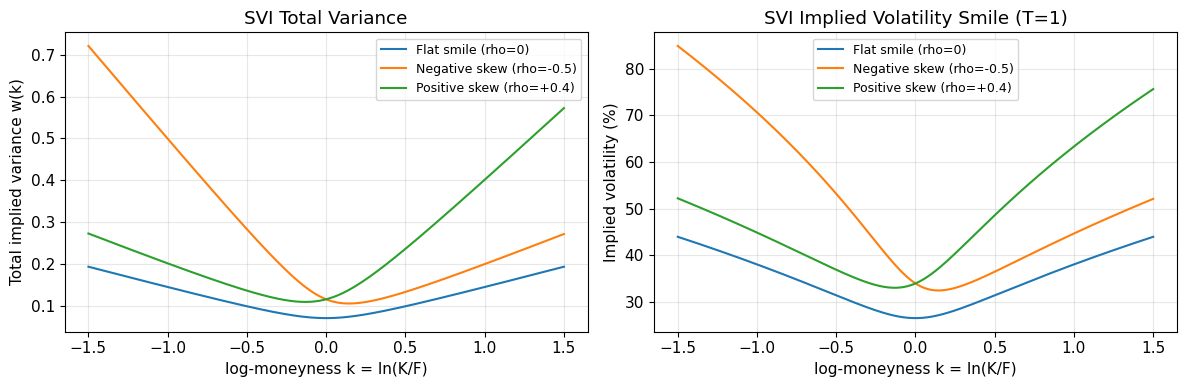

In [2]:
k = np.linspace(-1.5, 1.5, 300)
T = 1.0

scenarios = {
    'Flat smile (rho=0)':        SVIParams(a=0.04, b=0.10, rho=0.0,  m=0.0, sigma=0.30),
    'Negative skew (rho=-0.5)':  SVIParams(a=0.04, b=0.30, rho=-0.5, m=0.0, sigma=0.25),
    'Positive skew (rho=+0.4)':  SVIParams(a=0.04, b=0.25, rho=0.4,  m=0.0, sigma=0.30),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, p in scenarios.items():
    w  = svi_total_variance(k, p)
    iv = svi_implied_vol(k, T, p)
    axes[0].plot(k, w,  label=label)
    axes[1].plot(k, iv * 100, label=label)

axes[0].set_xlabel('log-moneyness k = ln(K/F)')
axes[0].set_ylabel('Total implied variance w(k)')
axes[0].set_title('SVI Total Variance')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('log-moneyness k = ln(K/F)')
axes[1].set_ylabel('Implied volatility (%)')
axes[1].set_title('SVI Implied Volatility Smile (T=1)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Parameter Sensitivity

How do each of the five SVI parameters affect the smile shape?

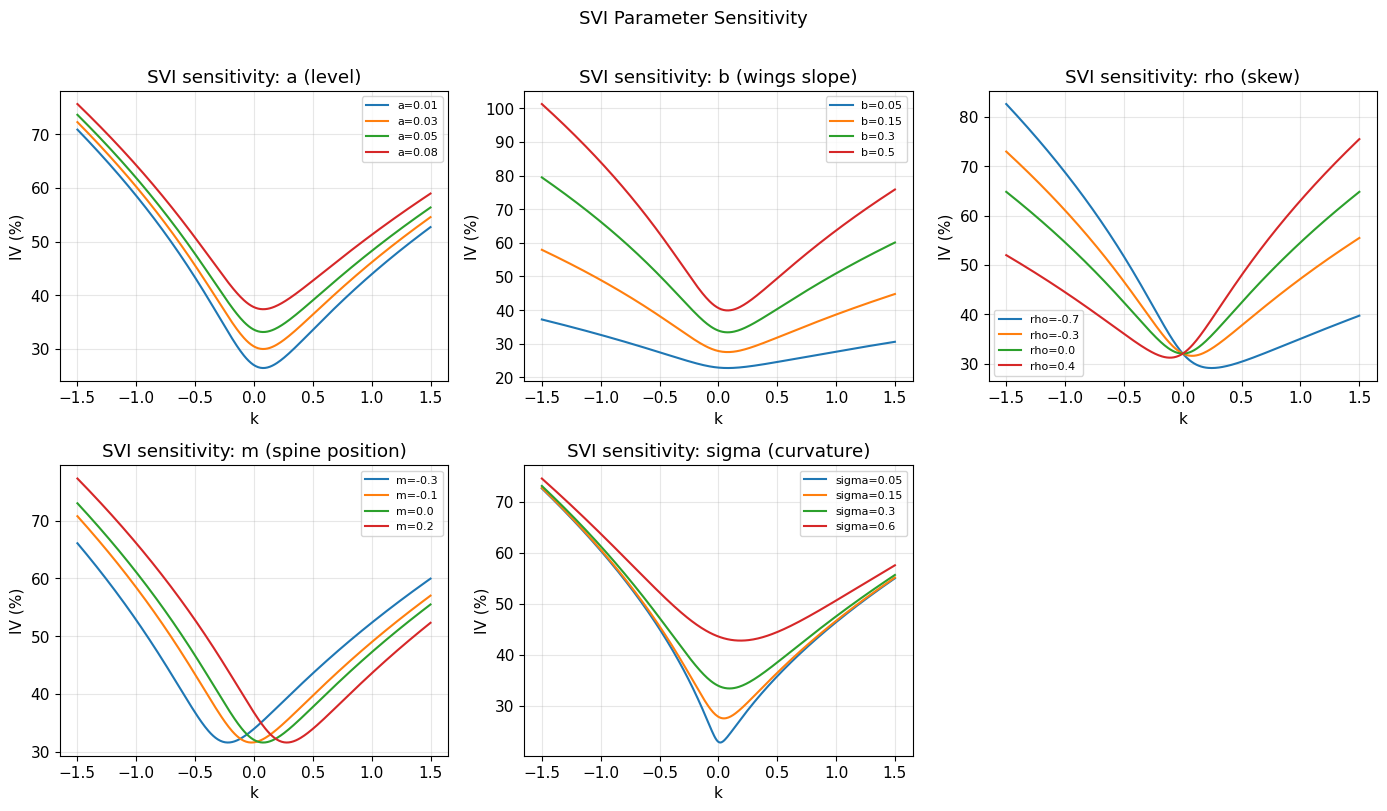

In [3]:
base = SVIParams(a=0.04, b=0.25, rho=-0.3, m=0.0, sigma=0.25)

param_sweeps = [
    ('a',     [0.01, 0.03, 0.05, 0.08], 'a (level)'),
    ('b',     [0.05, 0.15, 0.30, 0.50], 'b (wings slope)'),
    ('rho',   [-0.7, -0.3, 0.0, 0.4],   'rho (skew)'),
    ('m',     [-0.3, -0.1, 0.0, 0.2],   'm (spine position)'),
    ('sigma', [0.05, 0.15, 0.30, 0.60], 'sigma (curvature)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (param, values, title) in zip(axes, param_sweeps):
    for v in values:
        kwargs = dict(a=base.a, b=base.b, rho=base.rho, m=base.m, sigma=base.sigma)
        kwargs[param] = v
        try:
            p = SVIParams(**kwargs)
            iv = svi_implied_vol(k, T, p) * 100
            ax.plot(k, iv, label=f'{param}={v}')
        except ValueError:
            pass  # skip invalid boundary combinations
    ax.set_title(f'SVI sensitivity: {title}')
    ax.set_xlabel('k')
    ax.set_ylabel('IV (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('SVI Parameter Sensitivity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Butterfly Arbitrage Check

The risk-neutral density weight $g(k)$ must be non-negative everywhere for no butterfly arbitrage (Gatheral-Jacquier 2014):

$$g(k) = \left(1 - \frac{k\, w'(k)}{2w(k)}\right)^2 - \frac{w'(k)^2}{4}\left(\frac{1}{4} + \frac{1}{w(k)}\right) + \frac{w''(k)}{2} \geq 0$$

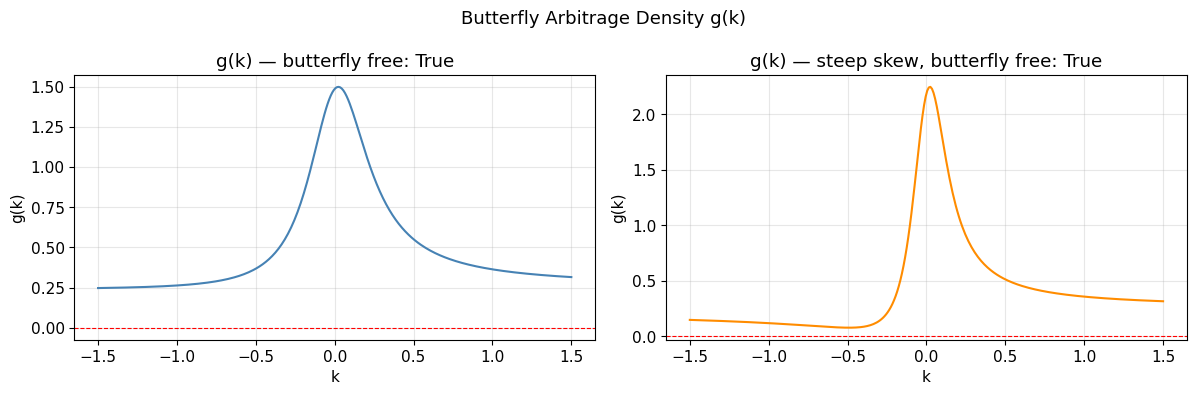

Safe params butterfly-free: True
Steep skew butterfly-free:  True


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

p_safe = SVIParams(a=0.04, b=0.25, rho=-0.3, m=0.0, sigma=0.25)
g_safe = svi_butterfly_density(k, p_safe)
bf_free = svi_check_butterfly_arbitrage(p_safe)

axes[0].plot(k, g_safe, color='steelblue')
axes[0].axhline(0, color='r', lw=0.8, ls='--')
axes[0].set_title(f'g(k) — butterfly free: {bf_free}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('g(k)')
axes[0].grid(True, alpha=0.3)

p_skew = SVIParams(a=0.04, b=0.40, rho=-0.6, m=0.0, sigma=0.15)
g_skew = svi_butterfly_density(k, p_skew)
bf_skew = svi_check_butterfly_arbitrage(p_skew)

axes[1].plot(k, g_skew, color='darkorange')
axes[1].axhline(0, color='r', lw=0.8, ls='--')
axes[1].set_title(f'g(k) — steep skew, butterfly free: {bf_skew}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('g(k)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Butterfly Arbitrage Density g(k)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Safe params butterfly-free: {bf_free}')
print(f'Steep skew butterfly-free:  {bf_skew}')

## 4. Single-Maturity Calibration to a Heston Smile

We generate a Heston implied-vol smile using the COS pricer, then fit SVI to it.

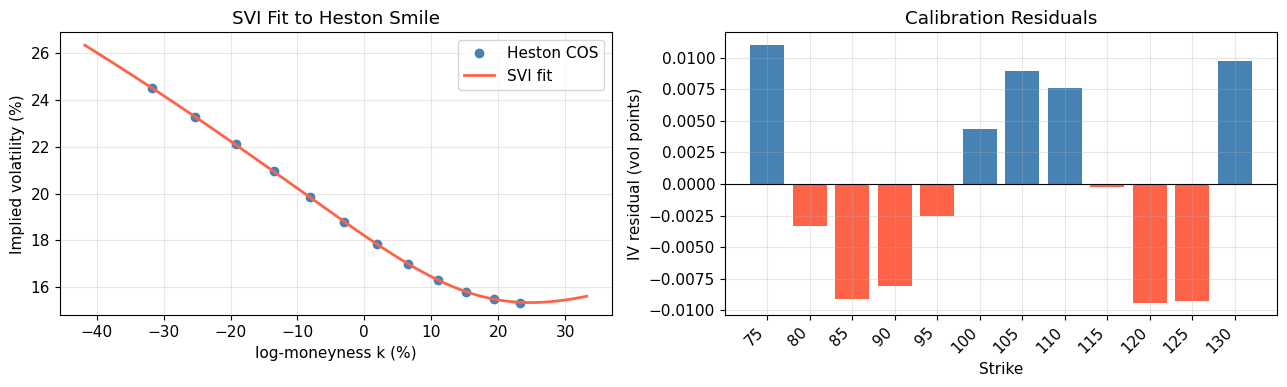

SVI parameters: a=0.0098  b=0.0715  rho=-0.3693  m=0.1662  sigma=0.2072
RMSE: 0.0077 vol pts | Max err: 0.0110 vol pts
Butterfly-free: True


In [5]:
def heston_iv_smile(heston_params, S0, r, q, T_mat, strikes):
    """Heston IV smile from COS pricer + Newton IV inversion."""
    fwd  = fe.ForwardSpec(S0=S0, r=r, q=q, T=T_mat)
    F0   = S0 * np.exp((r - q) * T_mat)
    grid = fe.cos_auto_grid(fe.heston_cumulants(fwd, heston_params), N=256, L=12.0)
    cf   = lambda u: fe.heston_cf_form2(u, fwd, heston_params)
    res  = fe.cos_prices(cf, fwd, strikes, grid)
    call_px = res.call_prices
    iv = np.array([
        fe.implied_vol_newton_safeguarded(
            float(c),
            fe.BSInputs(float(F0), float(K), float(T_mat), float(r), float(q), True)
        )
        for K, c in zip(strikes, call_px)
    ])
    return iv


S0 = 100.0
r, q = 0.05, 0.02
T_calib = 1.0

heston = fe.HestonParams(kappa=2.0, theta=0.04, nu=0.5, rho=-0.6, v0=0.04)
F      = S0 * np.exp((r - q) * T_calib)

strikes = np.array([75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130], dtype=float)
log_m   = np.log(strikes / F)

iv_heston = heston_iv_smile(heston, S0, r, q, T_calib, strikes)

# Fit SVI
result = fit_svi_smile(log_m, iv_heston, T_calib)

k_dense = np.linspace(log_m.min() - 0.1, log_m.max() + 0.1, 200)
iv_svi  = svi_implied_vol(k_dense, T_calib, result.params)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(log_m * 100, iv_heston * 100, 'o', color='steelblue', label='Heston COS', ms=6)
axes[0].plot(k_dense * 100, iv_svi * 100, '-', color='tomato', label='SVI fit', lw=2)
axes[0].set_xlabel('log-moneyness k (%)')
axes[0].set_ylabel('Implied volatility (%)')
axes[0].set_title('SVI Fit to Heston Smile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

resid = (svi_implied_vol(log_m, T_calib, result.params) - iv_heston) * 100
bar_colors = ['tomato' if v < 0 else 'steelblue' for v in resid]
axes[1].bar(range(len(strikes)), resid, color=bar_colors)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xticks(range(len(strikes)))
axes[1].set_xticklabels([f'{int(K)}' for K in strikes], rotation=45, ha='right')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('IV residual (vol points)')
axes[1].set_title('Calibration Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

p = result.params
print(f'SVI parameters: a={p.a:.4f}  b={p.b:.4f}  rho={p.rho:.4f}  m={p.m:.4f}  sigma={p.sigma:.4f}')
print(f'RMSE: {result.rmse*100:.4f} vol pts | Max err: {result.max_err*100:.4f} vol pts')
print(f'Butterfly-free: {result.butterfly_free}')

## 5. Term Structure: Fitting SVI Across Maturities

We fit SVI independently to each maturity slice and verify that total variance is
(approximately) non-decreasing across maturities — necessary for no calendar-spread arbitrage.

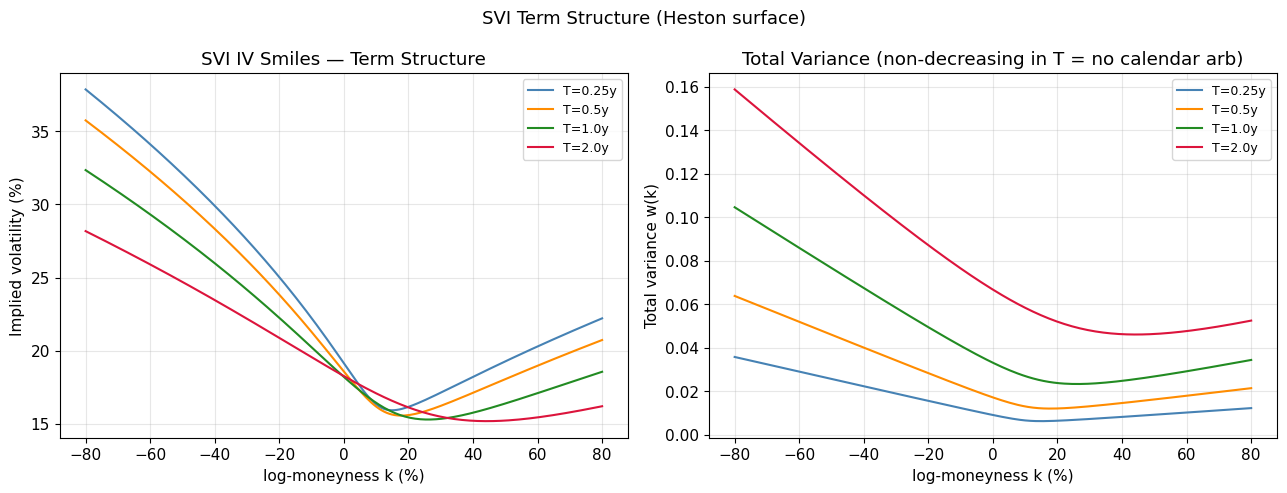


Calibration summary:
     T  RMSE (bp)  MaxErr (bp)  BF-free
  0.25       9.29        18.93     True
  0.50       5.66        10.42     True
  1.00       1.35         2.61     True
  2.00       0.15         0.21     True


In [6]:
maturities = [0.25, 0.5, 1.0, 2.0]
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
k_plot = np.linspace(-0.8, 0.8, 200)

svi_fits = {}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for T_i, col in zip(maturities, colors):
    F_i = S0 * np.exp((r - q) * T_i)
    K_i = F_i * np.exp(np.linspace(-0.6, 0.6, 13))
    k_i = np.log(K_i / F_i)

    iv_i  = heston_iv_smile(heston, S0, r, q, T_i, K_i)
    res_i = fit_svi_smile(k_i, iv_i, T_i)
    svi_fits[T_i] = res_i

    iv_model = svi_implied_vol(k_plot, T_i, res_i.params) * 100
    w_model  = svi_total_variance(k_plot, res_i.params)

    axes[0].plot(k_plot * 100, iv_model, color=col, label=f'T={T_i}y')
    axes[1].plot(k_plot * 100, w_model,  color=col, label=f'T={T_i}y')

axes[0].set_xlabel('log-moneyness k (%)')
axes[0].set_ylabel('Implied volatility (%)')
axes[0].set_title('SVI IV Smiles — Term Structure')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('log-moneyness k (%)')
axes[1].set_ylabel('Total variance w(k)')
axes[1].set_title('Total Variance (non-decreasing in T = no calendar arb)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SVI Term Structure (Heston surface)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCalibration summary:')
print(f'{"T":>6} {"RMSE (bp)":>10} {"MaxErr (bp)":>12} {"BF-free":>8}')
for T_i, res in svi_fits.items():
    print(f'{T_i:>6.2f} {res.rmse*10000:>10.2f} {res.max_err*10000:>12.2f} {str(res.butterfly_free):>8}')

## 6. SVI vs SABR Comparison

Both SABR and SVI are single-maturity smile parameterizations with 4-5 parameters.
We compare their fit quality on the same Heston smile.

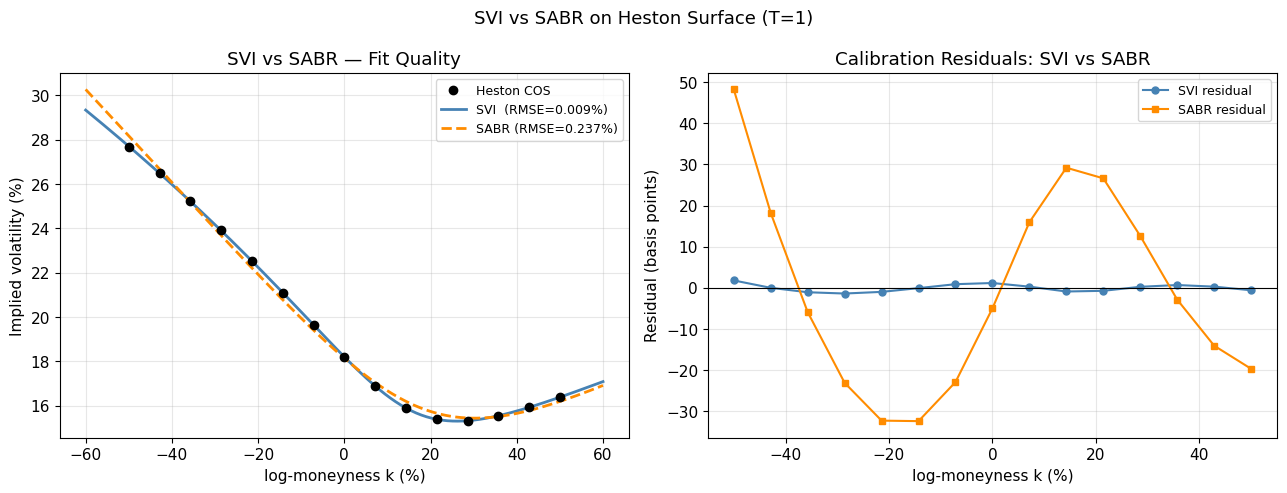

SVI:  RMSE = 0.0089%,  MaxErr = 0.0182%
SABR: RMSE = 0.2369%,  MaxErr = 0.4821%


In [7]:
from foureng.surface.calibration import calibrate_sabr_smile

T_comp = 1.0
F_comp = S0 * np.exp((r - q) * T_comp)
K_comp = F_comp * np.exp(np.linspace(-0.5, 0.5, 15))
k_comp = np.log(K_comp / F_comp)

iv_comp = heston_iv_smile(heston, S0, r, q, T_comp, K_comp)

# Fit SVI
svi_r = fit_svi_smile(k_comp, iv_comp, T_comp)

# Fit SABR (alpha, nu, rho with beta fixed at 0.5)
F_atm        = float(F_comp)
initial_sabr = fe.SabrParams(alpha=0.25, beta=0.5, rho=-0.3, nu=0.5)
sabr_r       = calibrate_sabr_smile(F_atm, T_comp, K_comp, iv_comp, initial_sabr)
sabr_kwargs  = {ki: v for ki, v in vars(sabr_r.params).items() if ki != 'name'}

# Compute SABR RMSE from residuals
sabr_rmse    = float(np.sqrt(np.mean(sabr_r.residuals**2)))
sabr_max_err = float(np.max(np.abs(sabr_r.residuals)))

k_dense = np.linspace(-0.6, 0.6, 300)
K_dense = F_comp * np.exp(k_dense)

iv_svi_dense  = svi_implied_vol(k_dense, T_comp, svi_r.params) * 100
iv_sabr_dense = np.array([
    fe.sabr_hagan_implied_vol(F_atm, float(K), T_comp, **sabr_kwargs)
    for K in K_dense
]) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_comp * 100, iv_comp * 100, 'o', color='k', label='Heston COS', ms=6, zorder=5)
axes[0].plot(k_dense * 100, iv_svi_dense,  '-',
             color='steelblue',  label=f'SVI  (RMSE={svi_r.rmse*100:.3f}%)', lw=2)
axes[0].plot(k_dense * 100, iv_sabr_dense, '--',
             color='darkorange', label=f'SABR (RMSE={sabr_rmse*100:.3f}%)', lw=2)
axes[0].set_xlabel('log-moneyness k (%)')
axes[0].set_ylabel('Implied volatility (%)')
axes[0].set_title('SVI vs SABR — Fit Quality')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

iv_svi_at_k  = svi_implied_vol(k_comp, T_comp, svi_r.params)
iv_sabr_at_k = np.array([
    fe.sabr_hagan_implied_vol(F_atm, float(K), T_comp, **sabr_kwargs)
    for K in K_comp
])

axes[1].plot(k_comp * 100, (iv_svi_at_k  - iv_comp) * 10000, 'o-',
             color='steelblue',  label='SVI residual',  ms=5)
axes[1].plot(k_comp * 100, (iv_sabr_at_k - iv_comp) * 10000, 's-',
             color='darkorange', label='SABR residual', ms=5)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('log-moneyness k (%)')
axes[1].set_ylabel('Residual (basis points)')
axes[1].set_title('Calibration Residuals: SVI vs SABR')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SVI vs SABR on Heston Surface (T=1)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'SVI:  RMSE = {svi_r.rmse*100:.4f}%,  MaxErr = {svi_r.max_err*100:.4f}%')
print(f'SABR: RMSE = {sabr_rmse*100:.4f}%,  MaxErr = {sabr_max_err*100:.4f}%')